In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
ts = [27.9638, 25.1961, 25.3349, 25.2279, 25.4944, 27.7243, 28.1656, 27.9733, 28.1068, 27.9484, 31.2998, 31.2538, 31.4739, 31.2479, 31.3048, 35.0098, 35.1414, 35.1585, 35.0010, 34.9252, 39.4415, 39.2334, 39.4646, 39.3616, 39.3679, 44.4304, 44.3198, 44.6615, 44.4225, 44.8999, 50.4790, 50.7962, 50.5700, 50.4366, 50.4816, 56.9668, 56.7304, 56.9796, 56.7557, 56.8724, 62.5773, 62.8245, 62.6603, 62.7544, 62.8098]

t_mean = []
t_std = []

for k in range(len([10000,15000,20000,25000,30000,35000,40000,45000,49302])):
    tmp = ts[k*5:k*5+5]
    t_mean.append(np.mean(tmp))
    t_std.append(np.std(tmp))

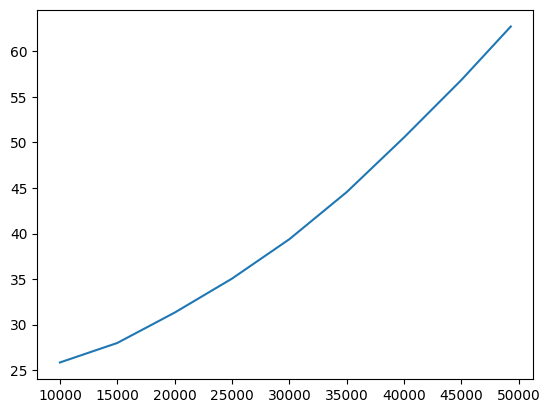

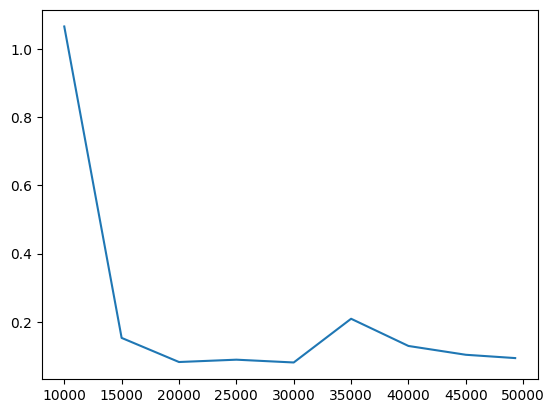

In [3]:
plt.plot([10000,15000,20000,25000,30000,35000,40000,45000,49302], t_mean)
plt.show()

plt.plot([10000,15000,20000,25000,30000,35000,40000,45000,49302], t_std)
plt.show()

In [4]:
t_std

[1.0652987325628425,
 0.15289462253460764,
 0.08225172581776036,
 0.08908257742117687,
 0.08089961680996796,
 0.20898045267440732,
 0.1292730814980442,
 0.10347367587942263,
 0.09376213734765236]

In [5]:
m, b = np.polyfit([1.5,2,2.5,3,3.5,4,4.5,4.9302], t_mean[1:], 1)
print(f"Equation: y = {m}x + {b}")

np.corrcoef([1.5,2,2.5,3,3.5,4,4.5,4.9302], t_mean[1:])[0][1]**2

Equation: y = 10.166990142669652x + 10.596794025318447


0.9850699935091091

回归方程: y = 0.0009370420470001841x + 249.57202251763954
R^2: 0.9293354165436569


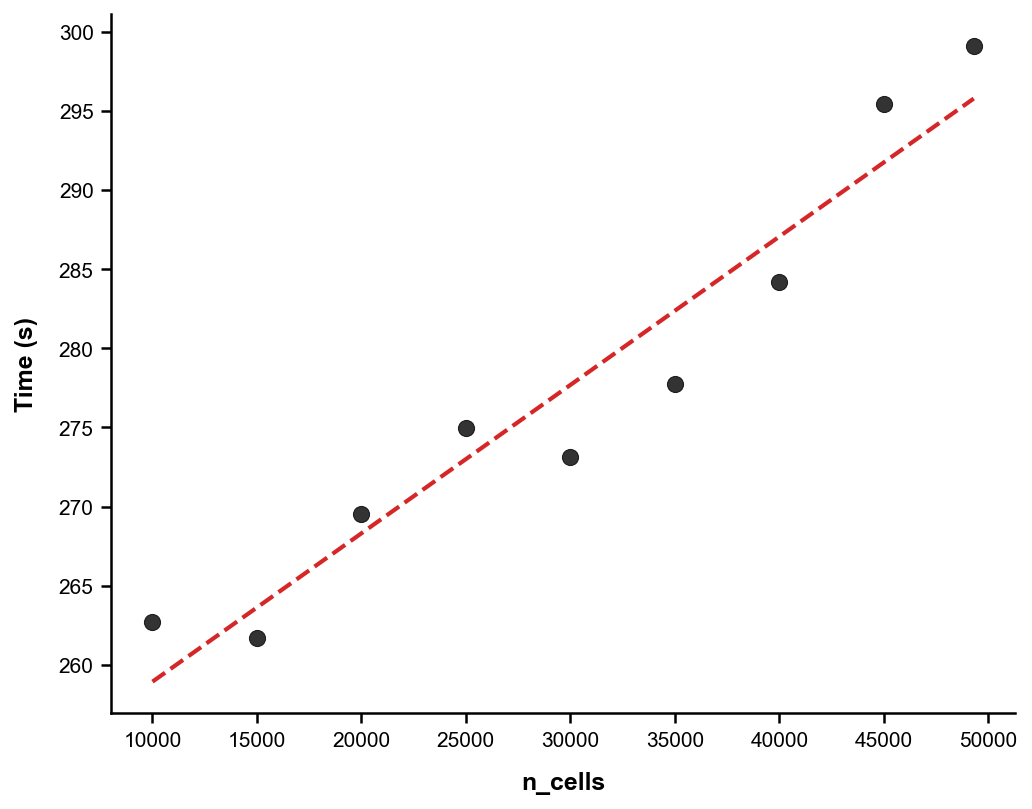

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- 数据准备 ---
# 纵坐标：Time (s)
y = np.array([262.6934, 261.6978, 269.5203, 274.9816, 
              273.1247, 277.7477, 284.1894, 295.4381, 299.1025])

# 横坐标：n_cells (真实值)
x = np.array([10000, 15000, 20000, 25000, 
              30000, 35000, 40000, 45000, 49302])

# --- 线性回归计算 ---
# 使用真实 x 值进行拟合，这样画出来的线才对应坐标轴
m, b = np.polyfit(x, y, 1)

# 计算相关系数 R^2
correlation_matrix = np.corrcoef(x, y)
r_squared = correlation_matrix[0, 1]**2

# --- 绘图设置 ---
# 设置全局字体为 Arial (科研常用无衬线字体)
plt.rcParams['font.family'] = 'Arial'
# 设置绘图尺寸和分辨率
fig, ax = plt.subplots(figsize=(7, 5.5), dpi=150)

# 1. 绘制散点 (使用不透明度 alpha 和 边缘色 edgecolor 增加质感)
ax.scatter(x, y, color='black', s=60, alpha=0.8, edgecolor='black', linewidth=0.5, label='Observed Data', zorder=3)

# 2. 绘制回归直线
y_fit = m * x + b
ax.plot(x, y_fit, color='#d62728', linewidth=2, linestyle='--', label='Linear Fit')

# --- 样式美化 (简约高级风) ---

# 去除上方和右方的边框 (Spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 加粗左方和下方的坐标轴线，使其更清晰
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# 设置坐标轴标签 (字号加大，增加距离 labelpad)
ax.set_xlabel('n_cells', fontsize=12, fontweight='demi', labelpad=10)
ax.set_ylabel('Time (s)', fontsize=12, fontweight='demi', labelpad=10)

# 设置刻度样式
ax.tick_params(axis='both', which='major', labelsize=10, width=1.2, length=5)

# 格式化 x 轴，若数字在科学计数法和普通数字间跳变的显示问题
# 这里我们保持普通数字显示，或者可以用科学计数法
# ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0)) 

# 添加图例文本 (显示公式和 R2)
# 位置放在左上角 (transform=ax.transAxes 相对坐标)
# equation_text = (f'$y = {m:.5f}x + {b:.2f}$\n'
#                  f'$R^2 = {r_squared:.4f}$')

# ax.text(0.05, 0.95, equation_text, transform=ax.transAxes, 
#         fontsize=11, verticalalignment='top', 
#         bbox=dict(boxstyle='square,pad=0.5', fc='white', ec='none', alpha=0.8))

# 调整布局防止标签被截断
plt.tight_layout()

# 打印控制台信息
print(f"回归方程: y = {m}x + {b}")
print(f"R^2: {r_squared}")

plt.savefig('n_cells_vs_time.png', dpi=300)
plt.show()